# 07 - Anomalib / PaDiM Model Evidence

**Purpose:** Document the professional anomaly detection model.

**Expected output:** GPU availability, PaDiM configuration, checkpoint status, metrics, and live PaDiM evidence.

**Platform connection:** PaDiM provides stronger anomaly localization than the OpenCV baseline.


In [1]:
from pathlib import Path
import json
import sys
import io
import logging
import warnings
from contextlib import redirect_stderr, redirect_stdout

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BOTTLE_DIR = PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection" / "bottle"
IMAGE_SIZE = (256, 256)
LABELS = ["good", "broken_large", "broken_small", "contamination"]


def read_rgb(path):
    image_bgr = cv2.imread(str(path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def first_image(label="contamination", split="test"):
    folder = BOTTLE_DIR / split / label
    images = sorted(folder.glob("*.png"))
    if not images:
        raise FileNotFoundError(f"No images found in {folder}")
    return images[0]


def show_grid(items, cols=4, figsize=(14, 7), suptitle=None):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, item in zip(axes, items):
        title, image, cmap = item
        ax.imshow(image, cmap=cmap)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("Project root:", PROJECT_ROOT)
print("MVTec bottle folder exists:", BOTTLE_DIR.exists())

import torch
from ml.config import MODEL_CHECKPOINT_PATH, MODEL_METADATA_PATH


def quiet_model_call(function, *args, **kwargs):
    """Run noisy model code while keeping notebook outputs presentation-clean."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        logging.disable(logging.CRITICAL)
        try:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                return function(*args, **kwargs)
        finally:
            logging.disable(logging.NOTSET)


Project root: C:\Users\HP\Desktop\springboard\visioninspect-ai-github
MVTec bottle folder exists: True


## Runtime And Artifact Status


In [2]:
display(pd.DataFrame([{
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only",
    "model": "PaDiM",
    "framework": "PyTorch / Anomalib",
    "category": "MVTec AD bottle",
}]))
display(pd.DataFrame([{
    "checkpoint_path": str(MODEL_CHECKPOINT_PATH),
    "checkpoint_exists": MODEL_CHECKPOINT_PATH.exists(),
    "checkpoint_size_mb": round(MODEL_CHECKPOINT_PATH.stat().st_size / (1024 * 1024), 2) if MODEL_CHECKPOINT_PATH.exists() else None,
    "metadata_path": str(MODEL_METADATA_PATH),
    "metadata_exists": MODEL_METADATA_PATH.exists(),
}]))


,torch_version,cuda_available,gpu_name,model,framework,category
0,2.11.0+cu128,True,NVIDIA GeForce RTX 4050 Laptop GPU,PaDiM,PyTorch / Anomalib,MVTec AD bottle


,checkpoint_path,checkpoint_exists,checkpoint_size_mb,metadata_path,metadata_exists
0,C:\Users\HP\Desktop\springboard\visioninspect-...,True,168.49,C:\Users\HP\Desktop\springboard\visioninspect-...,True


## Trained PaDiM Metrics


,project,model_name,model_version,dataset,category
0,VisionInspect AI,padim,v1,MVTec AD bottle,bottle


,metric,value
0,image_AUROC,0.998413
1,image_F1Score,0.983871
2,pixel_AUROC,0.982058
3,pixel_F1Score,0.713580


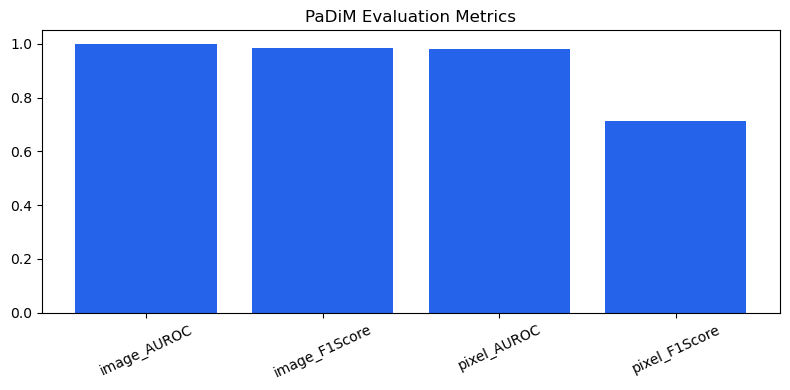

In [3]:
metadata = json.loads(MODEL_METADATA_PATH.read_text(encoding="utf-8")) if MODEL_METADATA_PATH.exists() else {"metrics": {}}
metrics_df = pd.DataFrame([{"metric": key, "value": value} for key, value in metadata.get("metrics", {}).items()])
display(pd.DataFrame([{"project": metadata.get("project"), "model_name": metadata.get("model_name"), "model_version": metadata.get("model_version"), "dataset": metadata.get("dataset"), "category": metadata.get("category")}]))
display(metrics_df)
if not metrics_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(metrics_df["metric"], metrics_df["value"], color="#2563eb")
    ax.set_ylim(0, 1.05)
    ax.set_title("PaDiM Evaluation Metrics")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()


## Baseline vs PaDiM vs Classifier


In [4]:
display(pd.DataFrame([
    {"method": "OpenCV baseline", "strength": "simple, explainable, fast", "limitation": "sensitive to lighting and handcrafted threshold"},
    {"method": "PaDiM anomaly detection", "strength": "learns normal feature distribution and localizes anomalies", "limitation": "requires trained checkpoint and heavier runtime"},
    {"method": "Defect classifier", "strength": "names the defect type", "limitation": "depends on labeled defect examples"},
]))


,method,strength,limitation
0,OpenCV baseline,"simple, explainable, fast",sensitive to lighting and handcrafted threshold
1,PaDiM anomaly detection,learns normal feature distribution and localiz...,requires trained checkpoint and heavier runtime
2,Defect classifier,names the defect type,depends on labeled defect examples


## Live PaDiM Inference Evidence


,image,engine,anomaly_score,decision_threshold,is_defective,detection_confidence
0,000.png,padim,0.679,0.5,True,0.9381


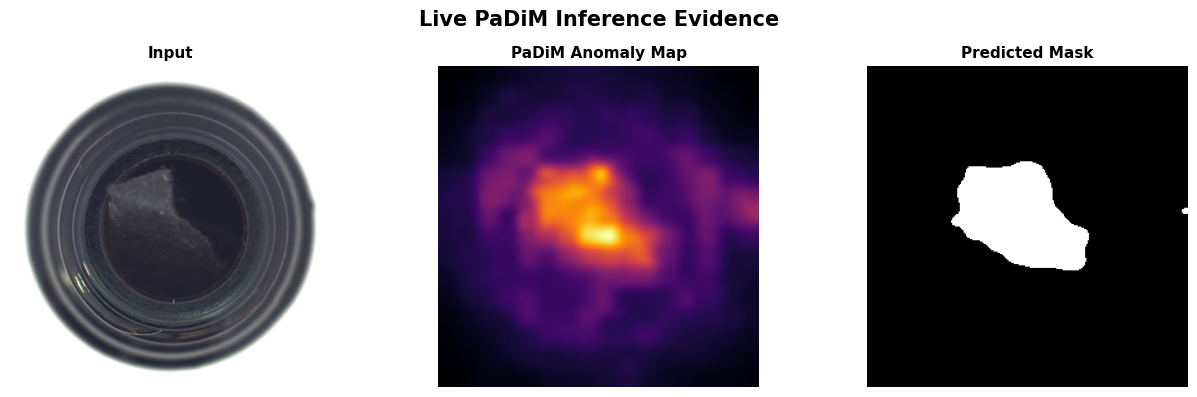

In [5]:
if MODEL_CHECKPOINT_PATH.exists():
    if str(PROJECT_ROOT / "backend") not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT / "backend"))
    from app.services.padim_service import predict_with_padim
    image_path = first_image("contamination", "test")
    pred = quiet_model_call(predict_with_padim, image_path, MODEL_CHECKPOINT_PATH)
    display(pd.DataFrame([{"image": image_path.name, "engine": pred["engine"], "anomaly_score": pred["anomaly_score"], "decision_threshold": pred["decision_threshold"], "is_defective": pred["is_defective"], "detection_confidence": pred["detection_confidence"]}]))
    show_grid([("Input", read_rgb(image_path), None), ("PaDiM Anomaly Map", pred["anomaly_map"], "inferno"), ("Predicted Mask", pred["pred_mask"], "gray")], cols=3, figsize=(13, 4), suptitle="Live PaDiM Inference Evidence")
else:
    display(Markdown("**Checkpoint not found. Showing stored metrics only.**"))


## PaDiM Architecture Summary

This explains why PaDiM is appropriate for manufacturing anomaly detection.


In [6]:
padim_architecture_df = pd.DataFrame([
    {"component": "normal-only training", "role": "learns expected appearance from good bottles"},
    {"component": "pretrained CNN features", "role": "extracts visual patterns without training from scratch"},
    {"component": "feature distribution model", "role": "models normal feature statistics per location"},
    {"component": "anomaly map", "role": "highlights pixels/regions that deviate from normal"},
    {"component": "image score", "role": "converts anomaly evidence into Good/Defective decision"},
])
display(padim_architecture_df)


,component,role
0,normal-only training,learns expected appearance from good bottles
1,pretrained CNN features,extracts visual patterns without training from...
2,feature distribution model,models normal feature statistics per location
3,anomaly map,highlights pixels/regions that deviate from no...
4,image score,converts anomaly evidence into Good/Defective ...


## Metric Interpretation


In [7]:
metric_interpretation_df = pd.DataFrame([
    {"metric": "image_AUROC", "meaning": "how well the model separates good vs defective images", "project_use": "inspection pass/fail confidence"},
    {"metric": "image_F1Score", "meaning": "balanced detection precision/recall at decision threshold", "project_use": "defect detection quality"},
    {"metric": "pixel_AUROC", "meaning": "how well anomaly pixels are localized", "project_use": "heatmap/mask quality"},
    {"metric": "pixel_F1Score", "meaning": "pixel mask overlap quality at threshold", "project_use": "localization reliability"},
])
display(metric_interpretation_df)


,metric,meaning,project_use
0,image_AUROC,how well the model separates good vs defective...,inspection pass/fail confidence
1,image_F1Score,balanced detection precision/recall at decisio...,defect detection quality
2,pixel_AUROC,how well anomaly pixels are localized,heatmap/mask quality
3,pixel_F1Score,pixel mask overlap quality at threshold,localization reliability


## Validation Outcome

- The project includes a professional anomaly detection model.
- PaDiM metrics prove image-level and pixel-level evaluation.
- The checkpoint can produce a live anomaly map when available.
